In [182]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

##### Ofertas de Venda

In [183]:
def load_sales_data(path):
    pattern = os.path.join(path, "apartments_pl_*.csv")
    arquivos = glob.glob(pattern)
    
    dfs = []
    
    for arquivo in arquivos:
        df = pd.read_csv(arquivo)
        nome_arquivo = os.path.basename(arquivo)
        mes = nome_arquivo.replace(".csv", "")[-2:]
        
        df["mes"] = int(mes)
        dfs.append(df)
    
    df_final = pd.concat(dfs, ignore_index=True)
    
    return df_final

df = load_sales_data("../dados/bruto")

df.to_csv("../dados/bruto/apartments_pl.csv", index=False)

##### Ofertas de Aluguel

In [184]:
def load_rent_data(path):
    pattern = os.path.join(path, "apartments_rent_pl*.csv")
    arquivos = glob.glob(pattern)

    dfs = []

    for arquivo in arquivos:
        df = pd.read_csv(arquivo)
        nome_arquivo = os.path.basename(arquivo)
        mes = nome_arquivo.replace(".csv", "")[-2:]

        df["mes"] = int(mes)
        dfs.append(df)

    df_final = pd.concat(dfs, ignore_index=True)

    return df_final

df = load_rent_data("../dados/bruto")
df.to_csv("../dados/bruto/apartments_rent.csv", index=False)

# Limpeza de Dados

### apartments_pl.csv

In [185]:
df = pd.read_csv("../dados/bruto/apartments_pl.csv")
df.head(5)

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,...,condominium,concreteSlab,NaN,yes,yes,yes,no,yes,415000,8
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,53.442692,14.559690,...,cooperative,concreteSlab,NaN,no,yes,yes,no,yes,395995,8
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,53.452222,14.553333,...,condominium,brick,NaN,no,no,no,no,no,565000,8
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,53.435100,14.532900,...,condominium,brick,NaN,yes,yes,no,no,yes,640000,8
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,53.410278,14.503611,...,condominium,NaN,NaN,no,no,no,no,no,759000,8


In [186]:
# Colunas do DataFrame
print(f"Quantidade de Colunas: {len(df.columns)}\n")
print(f"Nomes das Colunas: {df.columns}\n")

# Informaçoes do DataFrame
df.info()

Quantidade de Colunas: 29

Nomes das Colunas: Index(['id', 'city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'buildingMaterial', 'condition',
       'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity',
       'hasStorageRoom', 'price', 'mes'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195568 entries, 0 to 195567
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    195568 non-null  object 
 1   city                  195568 non-null  object 
 2   type                  153307 non-null  object 
 3   squareMeters          195568 non-null  float64
 4   rooms                 195568 

In [187]:
print(df['id'].value_counts())

id
7ec1e260b3f3985259ec7626756775c0    11
ad797d87b02e43385ae698e5ac35d56a    11
14ed649046f1ee52bbc19506c1787326    11
aad4eea5cda22c4572c675d9454d1cf6    11
01b9e6dc883ddd1a887b2a0eadc03965    11
                                    ..
0ab3b7a9d916e88f69eedc22e4e387fe     1
c3c469112e9aa1bad62a91f34654380d     1
00da3daf0afe6aa1ee8be95bedc3184c     1
9ebbaddd05ba76b732e7e4d99c2e3509     1
82be1337b948b7441823850de10cb335     1
Name: count, Length: 92967, dtype: int64


In [188]:
# Chegamos à conclusão que a ocorrência de duplicatas se dá pelo fato da ocorrência de vários anúncios para o mesmo imóvel, o que é comum em plataformas de venda e aluguel de imóveis.

df[df['id'] == '7ec1e260b3f3985259ec7626756775c0']

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
31,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,810000,8
18934,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,810000,9
35935,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,810000,10
52634,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,810000,11
68928,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,810000,12
85411,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,810000,1
100939,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,810000,2
117300,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,810000,3
135169,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,790000,4
154460,7ec1e260b3f3985259ec7626756775c0,szczecin,tenement,89.57,4.0,1.0,4.0,1930.0,53.432411,14.538777,...,condominium,brick,premium,no,no,NaN,no,no,790000,5


In [189]:
for coluna in df.columns:
    if df[coluna].isna().any():
        print(f"'{coluna}' possui valores nulos.")

print(f"\nQuantia de linhas com valores nulos: {df.isnull().any(axis=1).sum()}")

'type' possui valores nulos.
'floor' possui valores nulos.
'floorCount' possui valores nulos.
'buildYear' possui valores nulos.
'schoolDistance' possui valores nulos.
'clinicDistance' possui valores nulos.
'postOfficeDistance' possui valores nulos.
'kindergartenDistance' possui valores nulos.
'restaurantDistance' possui valores nulos.
'collegeDistance' possui valores nulos.
'pharmacyDistance' possui valores nulos.
'buildingMaterial' possui valores nulos.
'condition' possui valores nulos.
'hasElevator' possui valores nulos.

Quantia de linhas com valores nulos: 172141


##### Tratamento Coluna type

In [190]:
# Quantia de cada valor dentro da coluna "type"
print(df["type"].value_counts(dropna=False))

# Porcentagem de cada valor dentro da coluna "type"
valores = df["type"].value_counts(normalize=True, dropna=False) * 100
print(valores.map('{:.2f}%'.format))

type
blockOfFlats         91368
NaN                  42261
apartmentBuilding    32507
tenement             29432
Name: count, dtype: int64
type
blockOfFlats         46.72%
NaN                  21.61%
apartmentBuilding    16.62%
tenement             15.05%
Name: proportion, dtype: object


###### Não é inteligente nesse caso normalizar os valores NaN como a moda "blockOfFlats", isso pode prejudicar a compreensão dos padrões de preço em relação ao tipo de imóvel mais tarde quando for criar o modelo de ML. Optarei por atribuir os campos que se encontram NaN como "Desconhecido". É a abordagem mais prática e cumprirá o objetivo esperado.

In [191]:
df["type"].fillna("Desconecido", inplace=True)
df["type"].value_counts(normalize=True, dropna=False) * 100

C:\Users\berna\AppData\Local\Temp\ipykernel_35480\1202944264.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["type"].fillna("Desconecido", inplace=True)


type
blockOfFlats         46.719300
Desconecido          21.609363
apartmentBuilding    16.621840
tenement             15.049497
Name: proportion, dtype: float64

##### Tratamento Coluna floor

In [192]:
# Quantia de cada valor nulo dentro da coluna "floor"
print(len(df["floor"]))

# Quantia de cada valor nulo dentro da coluna "floor"
print(df["floor"].isnull().sum())

# Percentual de valores nulos dentro da coluna "floor"
print(df["floor"].isnull().sum() / len(df) * 100)

195568
34594
17.688987973492594


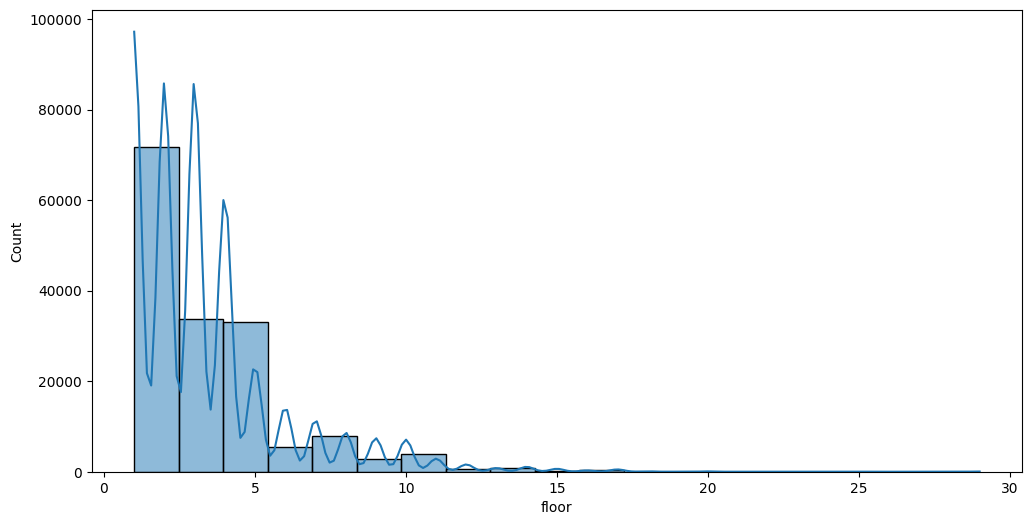

In [193]:
# Gerando visualização para estudar melhor maneira de lidar com os valores nulos da coluna "floor"

plt.figure(figsize=(12, 6))
sns.histplot(df["floor"], bins=30, binwidth=1.5, kde=True)
plt.show()

In [194]:
# Quantidade de valores em para cada andar
print(df["floor"].value_counts(dropna=True))

floor
1.0     38064
3.0     33823
2.0     33660
4.0     23953
5.0      9157
6.0      5565
7.0      4465
8.0      3392
9.0      2905
10.0     2777
11.0     1128
12.0      628
14.0      425
13.0      317
15.0      253
17.0      199
16.0      112
18.0       35
20.0       30
24.0       20
29.0       18
22.0       15
23.0       14
19.0        6
21.0        6
25.0        6
27.0        1
Name: count, dtype: int64


###### Verificando se os valores nulos da coluna "floor" tem algo a ver com o tipo de edificio

In [195]:
# Retorna DataFrame com linhas onde floor é NaN
linhas_nan_df = df[df['floor'].isna()]

# Exibe o DataFrame formatado
linhas_nan_df

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
11,ddff3f0ed9bb278617b6165aee8ab26c,szczecin,blockOfFlats,63.90,3.0,NaN,4.0,2000.0,53.365833,14.661389,...,cooperative,brick,NaN,no,yes,no,no,yes,545000,8
13,9ebbaddd05ba76b732e7e4d99c2e3509,szczecin,tenement,95.78,4.0,NaN,4.0,1945.0,53.432222,14.555833,...,condominium,brick,premium,no,no,no,no,yes,649000,8
30,efbd05715f9592339f2aee02017a77a6,szczecin,blockOfFlats,44.60,2.0,NaN,3.0,2016.0,53.404167,14.503333,...,condominium,NaN,premium,no,no,no,no,no,475000,8
35,355336466ec74696782ce382341086bd,szczecin,Desconecido,58.60,2.0,NaN,4.0,NaN,53.452774,14.477979,...,cooperative,brick,NaN,no,no,no,no,no,479000,8
38,98e40021de61a29b10f347c66744b51e,szczecin,blockOfFlats,92.32,3.0,NaN,2.0,1920.0,53.439754,14.520300,...,condominium,brick,NaN,yes,no,no,no,yes,489000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195547,b6b88869e699fad13b986a04de2261b2,bydgoszcz,blockOfFlats,47.00,3.0,NaN,NaN,NaN,53.112086,17.989945,...,condominium,NaN,NaN,no,yes,no,no,yes,319000,6
195551,a44ebb2effca197a3612f879ddeac767,bydgoszcz,tenement,39.40,2.0,NaN,NaN,1900.0,53.126000,18.007900,...,condominium,brick,low,no,no,no,no,yes,234000,6
195556,e2dc3b3752eb91a6cbc360e4daf028e0,bydgoszcz,tenement,72.00,4.0,NaN,2.0,1915.0,53.121200,17.992500,...,condominium,brick,NaN,no,no,no,no,no,399000,6
195562,4d5c0e9d63750d4e7ff183460b3fc8d1,bydgoszcz,tenement,100.76,3.0,NaN,2.0,1896.0,53.131234,18.006248,...,condominium,brick,NaN,yes,no,no,no,yes,670000,6


In [196]:
print(linhas_nan_df["type"].value_counts())

type
blockOfFlats         14694
Desconecido           8359
tenement              6387
apartmentBuilding     5154
Name: count, dtype: int64


###### Optei por remover as linhas onde "floor" == NaN, elas correspondem a 18% do dataset mas seria dificil fazer uma imputação coerente e não havia nenhuma relação de outro dado com a ausência de valores

In [197]:
df.dropna(subset=['floor'], inplace=True)
df.reset_index(drop=True, inplace=True)
df

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,...,condominium,concreteSlab,NaN,yes,yes,yes,no,yes,415000,8
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,53.442692,14.559690,...,cooperative,concreteSlab,NaN,no,yes,yes,no,yes,395995,8
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,53.452222,14.553333,...,condominium,brick,NaN,no,no,no,no,no,565000,8
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,53.435100,14.532900,...,condominium,brick,NaN,yes,yes,no,no,yes,640000,8
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,53.410278,14.503611,...,condominium,NaN,NaN,no,no,no,no,no,759000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160969,43ba1ff7e0804730281149d62fc9a48b,bydgoszcz,tenement,95.00,4.0,1.0,3.0,1893.0,53.126000,18.007900,...,condominium,brick,low,no,no,no,no,yes,599000,6
160970,ca83fdbc19c1e62e1cc6b6b21dcd5e03,bydgoszcz,Desconecido,54.00,3.0,4.0,4.0,NaN,53.126520,18.045220,...,condominium,NaN,NaN,no,yes,no,no,yes,460000,6
160971,bb19da639a2de8bba49be2ca49053c87,bydgoszcz,tenement,108.96,5.0,2.0,4.0,1889.0,53.131748,18.000648,...,condominium,brick,NaN,no,no,no,no,yes,795000,6
160972,1e7f4f1fdfea31eb84e071d697839632,bydgoszcz,Desconecido,50.12,2.0,1.0,1.0,NaN,53.129657,18.003888,...,condominium,brick,NaN,yes,no,no,no,no,360000,6


##### Tratamento Coluna floorCount

In [198]:
print(len(df["floorCount"]))

print(df["floorCount"].isnull().sum())

160974
0


###### Os valores nulos em floorCount foram resolvidos paralelamente aos da coluna floor

##### Tratamento Coluna buildYear

In [199]:
print(len(df["buildYear"]))

print(df["buildYear"].isnull().sum())

print(df["buildYear"].isnull().sum() / len(df) * 100)

160974
25845
16.05538782660554


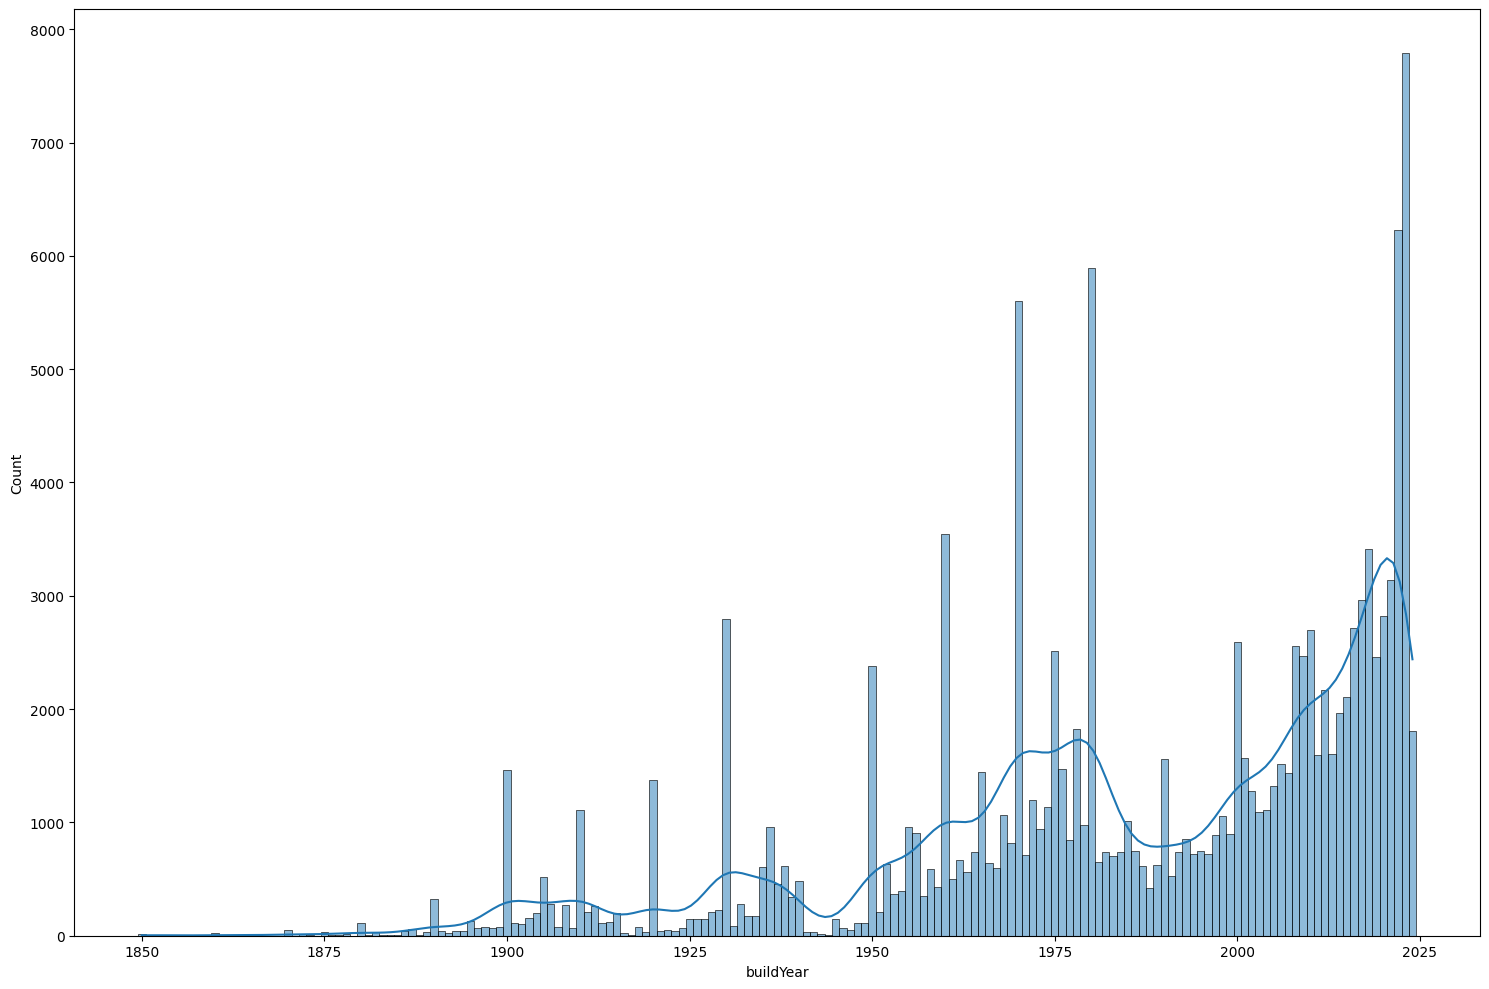

In [200]:
plt.figure(figsize=(15, 10))
sns.histplot(df["buildYear"], bins='auto', discrete=True, kde=True)
plt.tight_layout()
plt.show()

In [201]:
print(df["buildYear"].median())
print(df["buildYear"].mean())

1993.0
1986.1554070554803


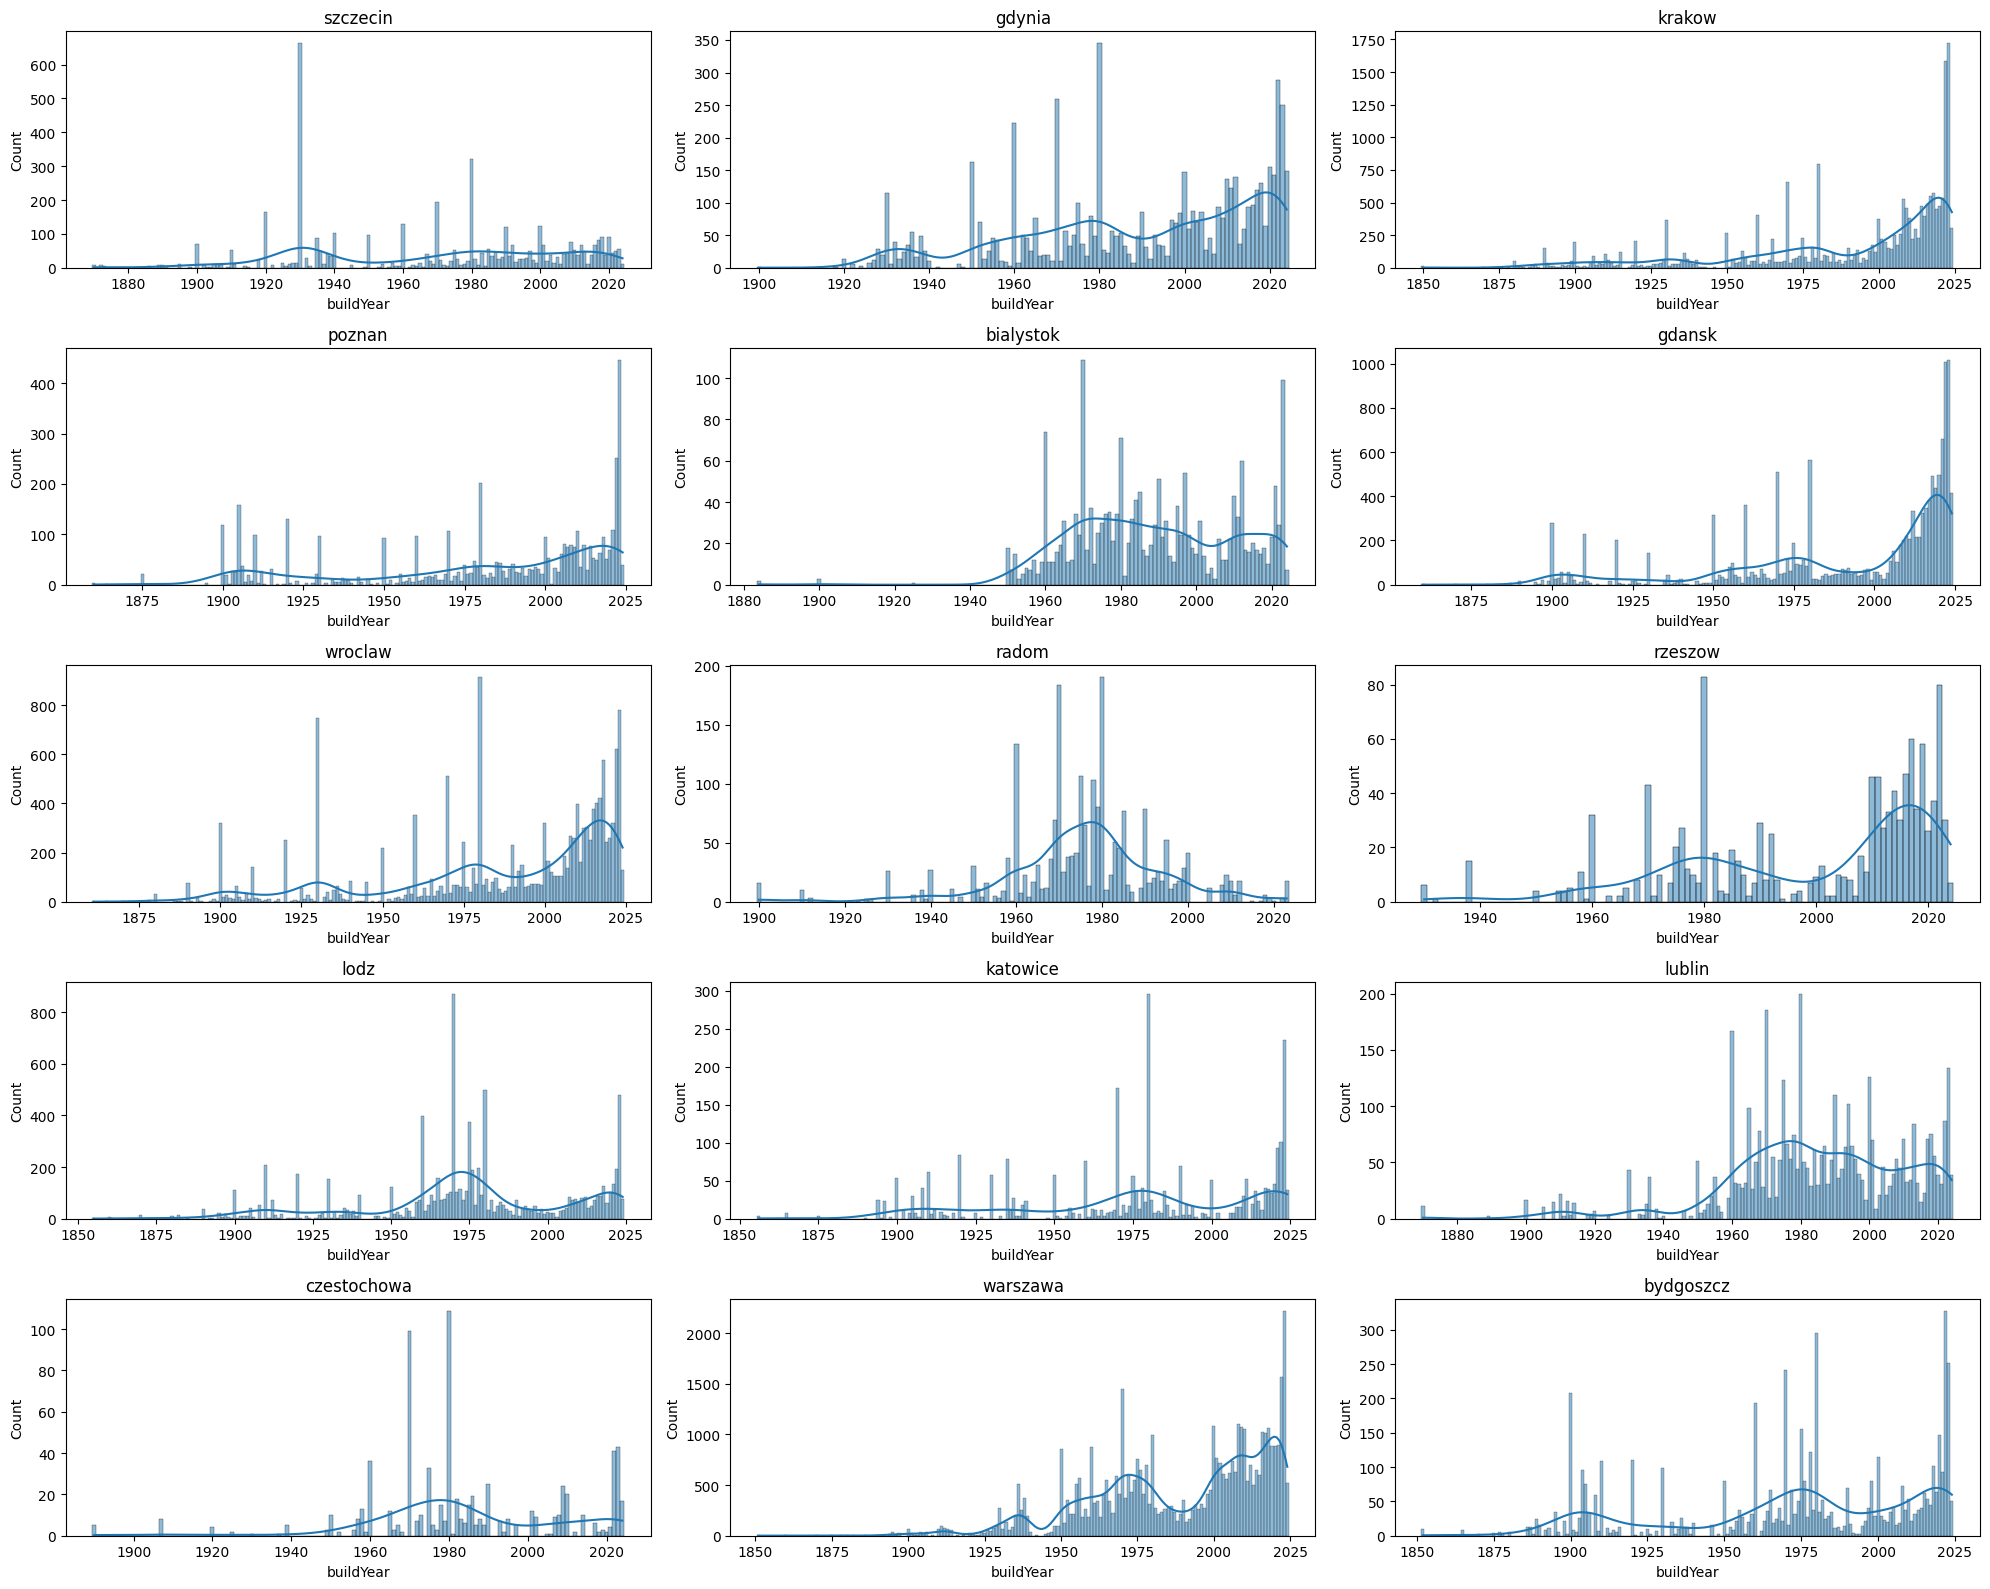

In [202]:
# Observando distribuição do buildYear para cada cidade

cidades = df["city"].unique()
fig, axes = plt.subplots(5, 3, figsize=(20, 16))
axes = axes.flatten()

for i, city in enumerate(cidades[:15]):
    sns.histplot(df[df["city"] == city]["buildYear"], bins='auto', discrete=True, kde=True, ax=axes[i])
    axes[i].set_title(city)

plt.tight_layout()
plt.show()

In [203]:
# Randomizando preenchimento de valores nulos da coluna "buildYear"

np.random.seed(42)
anos_random = np.random.randint(1960, 2026, size=df['buildYear'].isna().sum())
df.loc[df['buildYear'].isna(), 'buildYear'] = anos_random

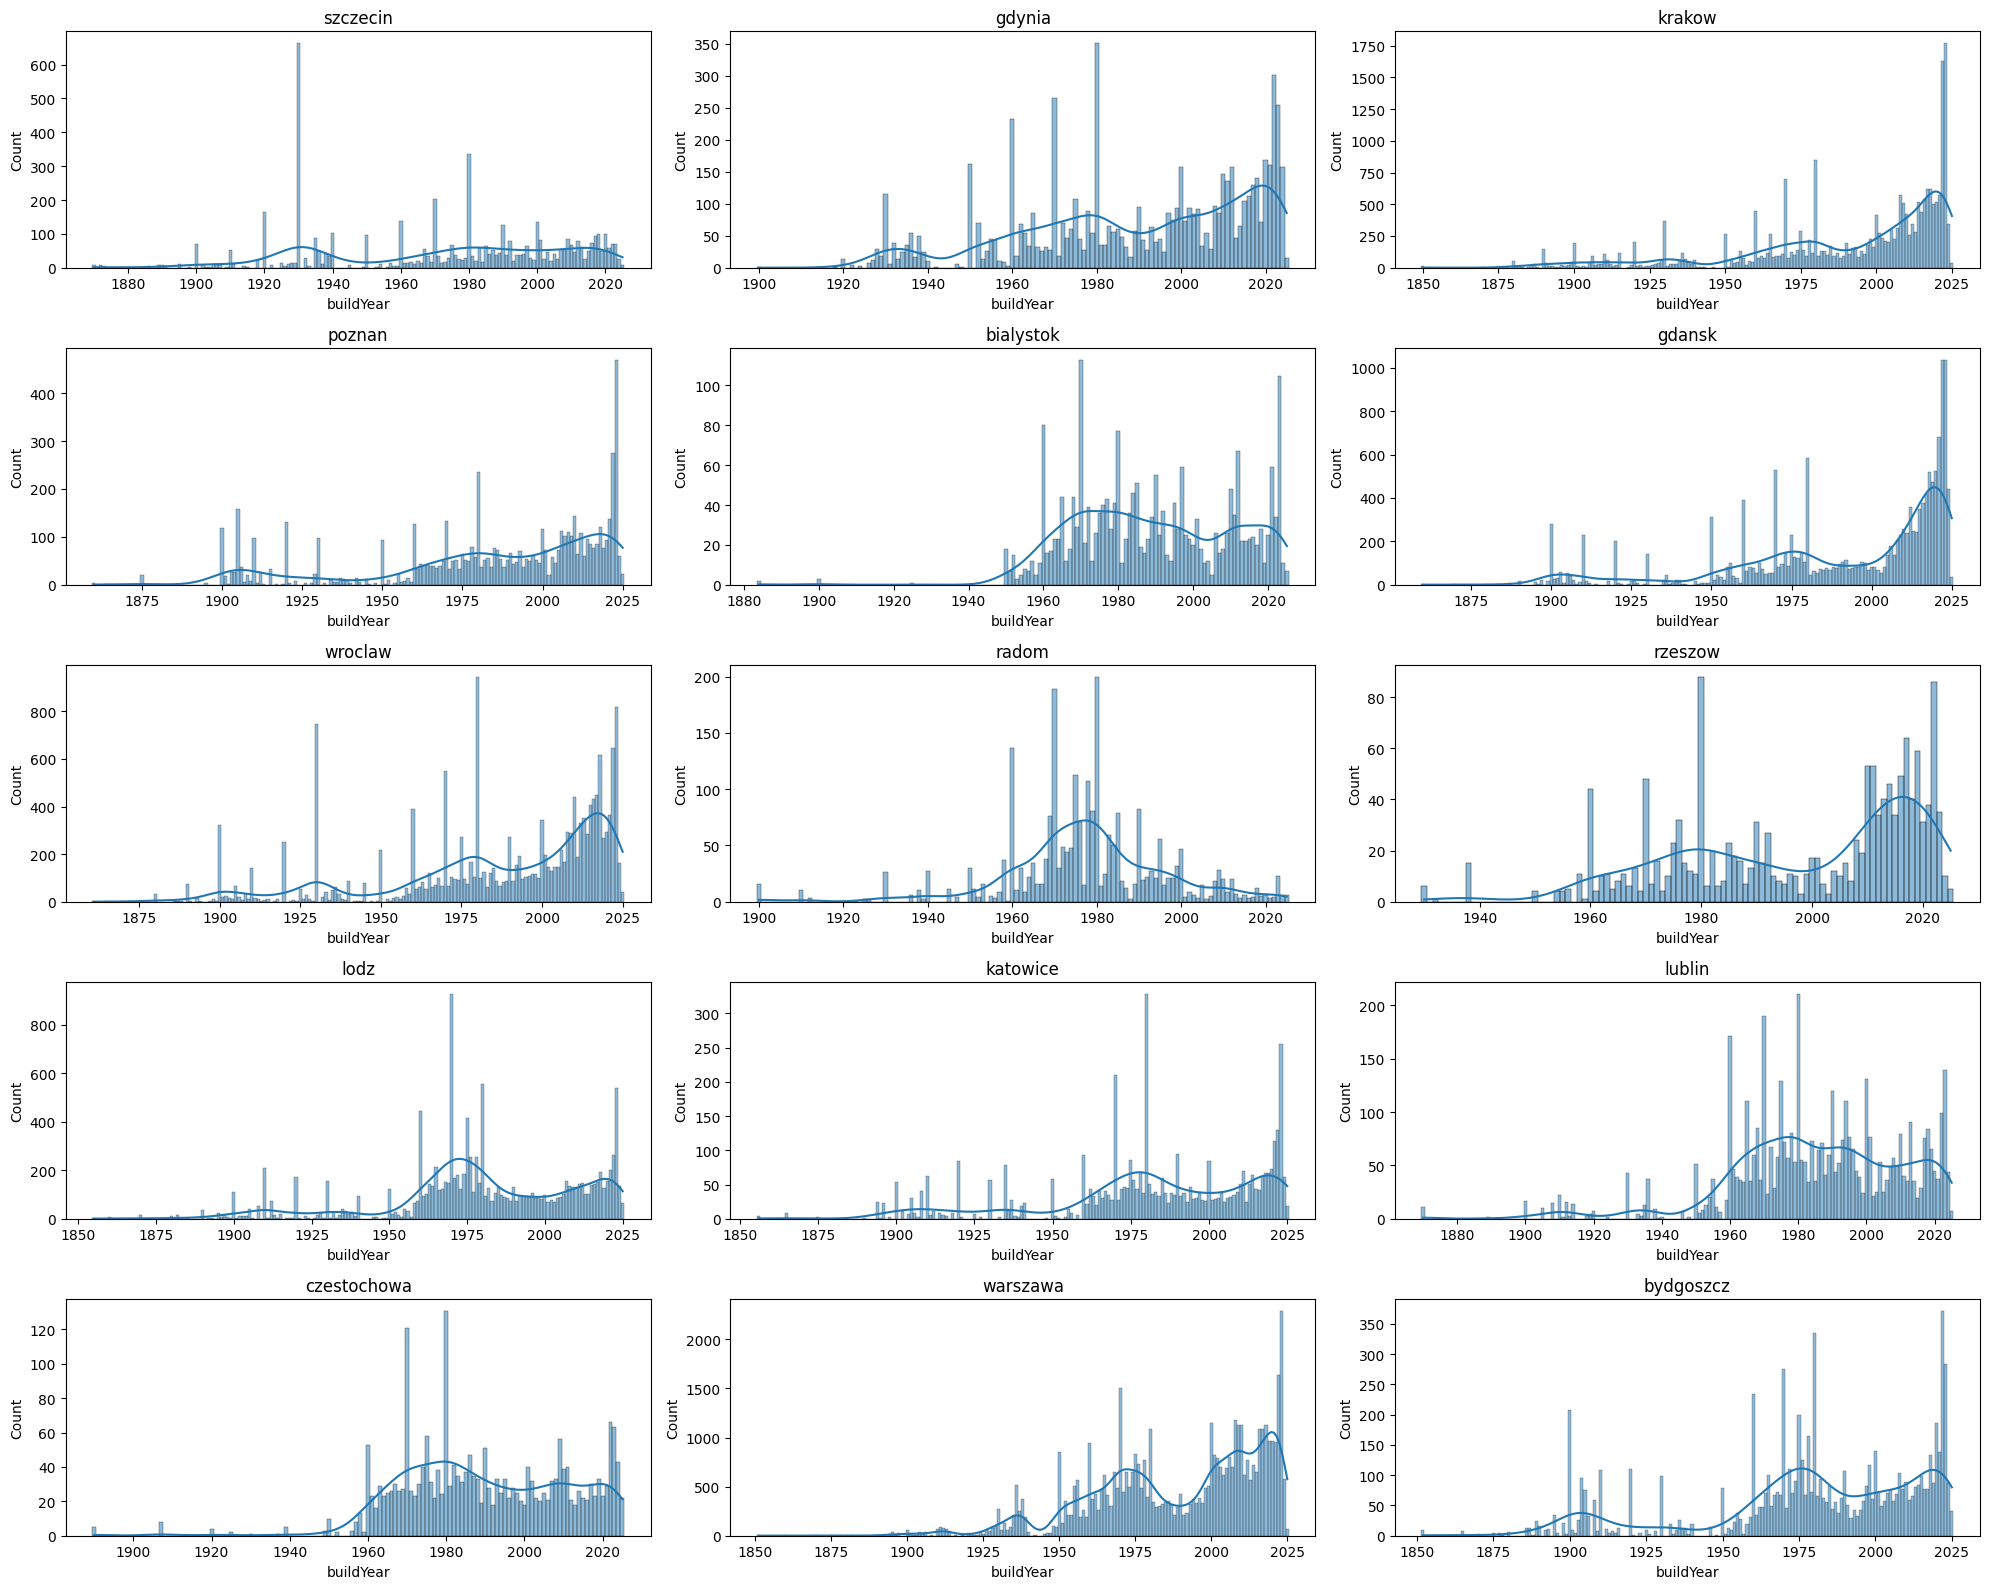

In [204]:
# USANDO MESMA GERAÇÃO DE GRAFICOS PARA CADA CIDADE APÓS O PREENCHIMENTO ALEATÓRIO

cidades = df["city"].unique()
fig, axes = plt.subplots(5, 3, figsize=(20, 16))
axes = axes.flatten()

for i, city in enumerate(cidades[:15]):
    sns.histplot(df[df["city"] == city]["buildYear"], bins='auto', discrete=True, kde=True, ax=axes[i])
    axes[i].set_title(city)

plt.tight_layout()
plt.show()

# Gostei dos resultados... Foram bem melhores do que quando tentei preencher com a mediana, que acabou criando um pico muito grande no gráfico. 
# O preenchimento aleatório deixou a distribuição mais natural, sem criar picos artificiais.

##### Tratamento Coluna schoolDistance

In [205]:
print(df["schoolDistance"].isnull().sum())

df.fillna({"schoolDistance": df["schoolDistance"].median()}, inplace=True)
print(df["schoolDistance"].isnull().sum())

131
0


##### Tratamento Coluna clinicDistance

In [206]:
print(df["clinicDistance"].isnull().sum())

df.fillna({"clinicDistance": df["clinicDistance"].median()}, inplace=True)
print(df["clinicDistance"].isnull().sum())

553
0


##### Tratamento Coluna kindergartenDistance

In [207]:
print(df["kindergartenDistance"].isnull().sum())

df.fillna({"kindergartenDistance": df["kindergartenDistance"].median()}, inplace=True)
print(df["kindergartenDistance"].isnull().sum())

172
0


##### Tratamento Coluna restaurantDistance

In [208]:
print(df["restaurantDistance"].isnull().sum())

df.fillna({"restaurantDistance": df["restaurantDistance"].median()}, inplace=True)
print(df["restaurantDistance"].isnull().sum())

410
0


##### Tratamento Coluna collegeDistance

In [209]:
print(df["collegeDistance"].isnull().sum())

df.fillna({"collegeDistance": df["collegeDistance"].median()}, inplace=True)
print(df["collegeDistance"].isnull().sum())

4233
0


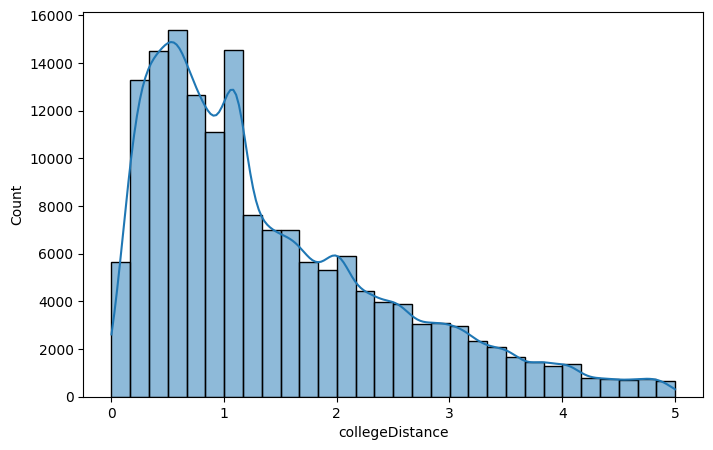

In [210]:
plt.figure(figsize=(8, 5))
sns.histplot(df["collegeDistance"], bins=30, kde=True)
plt.show()

##### Tratamento Coluna pharmacyDistance

In [211]:
print(df["pharmacyDistance"].isnull().sum())

df.fillna({"pharmacyDistance": df["pharmacyDistance"].median()}, inplace=True)
print(df["pharmacyDistance"].isnull().sum())

242
0


##### Tratamento Coluna buildingMaterial

In [212]:
print(df["buildingMaterial"].isnull().sum())

# A quantidade de valores nulos na coluna "buildingMaterial" é alta, o que pode indicar que essa informação não é tão crucial para a maioria dos imóveis 
# ou que os dados foram coletados de fontes onde essa informação não estava disponível. Vou então remover a coluna

df.drop(columns=["buildingMaterial"], inplace=True)
df

63476


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,...,0.413,condominium,NaN,yes,yes,yes,no,yes,415000,8
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,2011.0,53.442692,14.559690,...,0.205,cooperative,NaN,no,yes,yes,no,yes,395995,8
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,1974.0,53.452222,14.553333,...,0.280,condominium,NaN,no,no,no,no,no,565000,8
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,2020.0,53.435100,14.532900,...,0.087,condominium,NaN,yes,yes,no,no,yes,640000,8
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,1980.0,53.410278,14.503611,...,0.514,condominium,NaN,no,no,no,no,no,759000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160969,43ba1ff7e0804730281149d62fc9a48b,bydgoszcz,tenement,95.00,4.0,1.0,3.0,1893.0,53.126000,18.007900,...,0.205,condominium,low,no,no,no,no,yes,599000,6
160970,ca83fdbc19c1e62e1cc6b6b21dcd5e03,bydgoszcz,Desconecido,54.00,3.0,4.0,4.0,1971.0,53.126520,18.045220,...,0.062,condominium,NaN,no,yes,no,no,yes,460000,6
160971,bb19da639a2de8bba49be2ca49053c87,bydgoszcz,tenement,108.96,5.0,2.0,4.0,1889.0,53.131748,18.000648,...,0.143,condominium,NaN,no,no,no,no,yes,795000,6
160972,1e7f4f1fdfea31eb84e071d697839632,bydgoszcz,Desconecido,50.12,2.0,1.0,1.0,1997.0,53.129657,18.003888,...,0.250,condominium,NaN,yes,no,no,no,no,360000,6


##### Tratamento Coluna condition

In [213]:
print(df["condition"].isnull().sum())

# A quantidade de valores nulos na coluna "condition" é alta, o que pode indicar que essa informação não é tão crucial para a maioria dos imóveis
# ou que os dados foram coletados de fontes onde essa informação não estava disponível. Vou então remover a coluna

df.drop(columns=["condition"], inplace=True)
df

120209


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,collegeDistance,pharmacyDistance,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,...,1.097,0.413,condominium,yes,yes,yes,no,yes,415000,8
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,2011.0,53.442692,14.559690,...,1.404,0.205,cooperative,no,yes,yes,no,yes,395995,8
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,1974.0,53.452222,14.553333,...,1.857,0.280,condominium,no,no,no,no,no,565000,8
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,2020.0,53.435100,14.532900,...,0.310,0.087,condominium,yes,yes,no,no,yes,640000,8
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,1980.0,53.410278,14.503611,...,2.138,0.514,condominium,no,no,no,no,no,759000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160969,43ba1ff7e0804730281149d62fc9a48b,bydgoszcz,tenement,95.00,4.0,1.0,3.0,1893.0,53.126000,18.007900,...,0.622,0.205,condominium,no,no,no,no,yes,599000,6
160970,ca83fdbc19c1e62e1cc6b6b21dcd5e03,bydgoszcz,Desconecido,54.00,3.0,4.0,4.0,1971.0,53.126520,18.045220,...,0.614,0.062,condominium,no,yes,no,no,yes,460000,6
160971,bb19da639a2de8bba49be2ca49053c87,bydgoszcz,tenement,108.96,5.0,2.0,4.0,1889.0,53.131748,18.000648,...,0.226,0.143,condominium,no,no,no,no,yes,795000,6
160972,1e7f4f1fdfea31eb84e071d697839632,bydgoszcz,Desconecido,50.12,2.0,1.0,1.0,1997.0,53.129657,18.003888,...,0.332,0.250,condominium,yes,no,no,no,no,360000,6


##### Tratamento Coluna hasElevator

In [214]:
print(df["hasElevator"].isnull().sum())

print(df["hasElevator"].value_counts(dropna=False))

# Vou artificializar os valores nulos da coluna "hasElevator" com base na proporção dos valores existentes

7030
hasElevator
yes    79582
no     74362
NaN     7030
Name: count, dtype: int64


In [215]:
# Vou artificializar os valores nulos da coluna "hasElevator" com base na proporção dos valores existentes
df.loc[df['hasElevator'].isna(), 'hasElevator'] = np.random.choice(['yes','no'], df['hasElevator'].isna().sum(), p=[0.5,0.5])

print(df["hasElevator"].isnull().sum())

print(df["hasElevator"].value_counts(dropna=False))

0
hasElevator
yes    83017
no     77957
Name: count, dtype: int64


### ===================================================================================

In [216]:
df.to_csv("../dados/processado/apartments_pl_processed.csv", index=False)

### ===================================================================================

### apartments_rent.csv

In [217]:
df = pd.read_csv("../dados/bruto/apartments_rent.csv")
df.head(5)

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,condominium,brick,NaN,yes,yes,no,no,no,3500,11
1,5a0cb42c088eadf75aa98a4118640048,szczecin,blockOfFlats,57.0,3.0,NaN,10.0,1976.0,53.440955,14.566024,...,condominium,NaN,premium,no,yes,yes,no,no,3000,11
2,996722490efcb4b34d48bb84a9a72838,szczecin,NaN,43.4,2.0,3.0,4.0,NaN,53.435746,14.560764,...,condominium,NaN,NaN,no,yes,no,no,no,1900,11
3,50d75c688530b9a61ba505301e0b94a9,szczecin,apartmentBuilding,32.6,2.0,5.0,6.0,2021.0,53.421582,14.541572,...,condominium,brick,premium,no,yes,yes,no,no,2500,11
4,9b187f4203adabf466fd08610d8f4e5e,szczecin,apartmentBuilding,72.0,3.0,6.0,6.0,2014.0,53.450010,14.547230,...,condominium,brick,premium,no,yes,yes,no,yes,2999,11


In [218]:
# Colunas do DataFrame
print(f"Quantidade de Colunas: {len(df.columns)}\n")
print(f"Nomes das Colunas: {df.columns}\n")

# Informaçoes do DataFrame
df.info()

Quantidade de Colunas: 29

Nomes das Colunas: Index(['id', 'city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'buildingMaterial', 'condition',
       'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity',
       'hasStorageRoom', 'price', 'mes'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70847 entries, 0 to 70846
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    70847 non-null  object 
 1   city                  70847 non-null  object 
 2   type                  54085 non-null  object 
 3   squareMeters          70847 non-null  float64
 4   rooms                 70847 non-null 

In [219]:
print(df['id'].value_counts())

id
f669872f67ece87f8e8fce68ac27f31a    8
07f8e47f63ee7d56465cc8f83595db48    8
1780a045b59024a972947233a9d8b078    8
f4460cfb64e1ba7832566c32d57155b4    8
2f03df912e008a68c5a2f39b610d562e    8
                                   ..
ed9461e9da4db21c85fa9bb84a6e33cd    1
c246a1b58a8e0eeee65238461aef38d2    1
5d3ec6f0283e7308d1f165ccd118f54d    1
76944a5985ca0f9c11bc261854c7f5d2    1
872ce710071704670eada868273acd7a    1
Name: count, Length: 37941, dtype: int64


In [220]:
# Chegamos à conclusão que a ocorrência de duplicatas se dá pelo fato da ocorrência de vários anúncios para o mesmo imóvel, o que é comum em plataformas de venda e aluguel de imóveis.

df[df['id'] == '07f8e47f63ee7d56465cc8f83595db48']

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
53,07f8e47f63ee7d56465cc8f83595db48,szczecin,apartmentBuilding,38.0,2.0,2.0,5.0,2020.0,53.418611,14.549722,...,condominium,brick,premium,no,yes,yes,no,no,2400,11
8621,07f8e47f63ee7d56465cc8f83595db48,szczecin,apartmentBuilding,38.0,2.0,2.0,5.0,2020.0,53.418611,14.549722,...,condominium,brick,premium,no,yes,yes,no,no,2400,12
17488,07f8e47f63ee7d56465cc8f83595db48,szczecin,apartmentBuilding,38.0,2.0,2.0,5.0,2020.0,53.418611,14.549722,...,condominium,brick,premium,no,yes,yes,no,no,2400,1
25946,07f8e47f63ee7d56465cc8f83595db48,szczecin,apartmentBuilding,38.0,2.0,2.0,5.0,2020.0,53.418611,14.549722,...,condominium,brick,premium,no,yes,yes,no,no,2400,2
34277,07f8e47f63ee7d56465cc8f83595db48,szczecin,apartmentBuilding,38.0,2.0,2.0,5.0,2020.0,53.418611,14.549722,...,condominium,brick,premium,no,yes,yes,no,no,2400,3
43454,07f8e47f63ee7d56465cc8f83595db48,szczecin,apartmentBuilding,38.0,2.0,2.0,5.0,2020.0,53.418611,14.549722,...,condominium,brick,premium,no,yes,yes,no,no,2400,4
52943,07f8e47f63ee7d56465cc8f83595db48,szczecin,apartmentBuilding,38.0,2.0,2.0,5.0,2020.0,53.418611,14.549722,...,condominium,brick,premium,no,yes,yes,no,no,2400,5
62151,07f8e47f63ee7d56465cc8f83595db48,szczecin,apartmentBuilding,38.0,2.0,2.0,5.0,2020.0,53.418611,14.549722,...,condominium,brick,premium,no,yes,yes,no,no,2400,6


In [221]:
for coluna in df.columns:
    if df[coluna].isna().any():
        print(f"'{coluna}' possui valores nulos.")

print(f"\nQuantia de linhas com valores nulos: {df.isnull().any(axis=1).sum()}")

'type' possui valores nulos.
'floor' possui valores nulos.
'floorCount' possui valores nulos.
'buildYear' possui valores nulos.
'schoolDistance' possui valores nulos.
'clinicDistance' possui valores nulos.
'postOfficeDistance' possui valores nulos.
'kindergartenDistance' possui valores nulos.
'restaurantDistance' possui valores nulos.
'collegeDistance' possui valores nulos.
'pharmacyDistance' possui valores nulos.
'buildingMaterial' possui valores nulos.
'condition' possui valores nulos.
'hasElevator' possui valores nulos.

Quantia de linhas com valores nulos: 60641


##### Tratamento Coluna type

In [222]:
# Quantia de cada valor dentro da coluna "type"
print(df["type"].value_counts(dropna=False))

# Porcentagem de cada valor dentro da coluna "type"
valores = df["type"].value_counts(normalize=True, dropna=False) * 100
print(valores.map('{:.2f}%'.format))

type
apartmentBuilding    23910
blockOfFlats         22713
NaN                  16762
tenement              7462
Name: count, dtype: int64
type
apartmentBuilding    33.75%
blockOfFlats         32.06%
NaN                  23.66%
tenement             10.53%
Name: proportion, dtype: object


In [223]:
df["type"].fillna("Desconecido", inplace=True)
df["type"].value_counts(normalize=True, dropna=False) * 100

C:\Users\berna\AppData\Local\Temp\ipykernel_35480\1202944264.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["type"].fillna("Desconecido", inplace=True)


type
apartmentBuilding    33.748783
blockOfFlats         32.059226
Desconecido          23.659435
tenement             10.532556
Name: proportion, dtype: float64

##### Tratamento Coluna floor

In [224]:
# Quantia de cada valor nulo dentro da coluna "floor"
print(len(df["floor"]))

# Quantia de cada valor nulo dentro da coluna "floor"
print(df["floor"].isnull().sum())

# Percentual de valores nulos dentro da coluna "floor"
print(df["floor"].isnull().sum() / len(df) * 100)

70847
8613
12.157183790421614


In [225]:
# Quantidade de valores em para cada andar
print(df["floor"].value_counts(dropna=True))

floor
1.0     14484
2.0     13893
3.0     11173
4.0      8340
5.0      4758
6.0      2907
7.0      1929
8.0      1457
9.0       968
10.0      828
11.0      469
12.0      224
13.0      214
14.0      143
15.0      122
16.0      112
17.0       75
18.0       39
20.0       34
19.0       34
25.0        8
22.0        7
21.0        5
23.0        5
27.0        3
30.0        2
24.0        1
Name: count, dtype: int64


In [226]:
df.dropna(subset=['floor'], inplace=True)
df.reset_index(drop=True, inplace=True)
df

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,condominium,brick,NaN,yes,yes,no,no,no,3500,11
1,996722490efcb4b34d48bb84a9a72838,szczecin,Desconecido,43.4,2.0,3.0,4.0,NaN,53.435746,14.560764,...,condominium,NaN,NaN,no,yes,no,no,no,1900,11
2,50d75c688530b9a61ba505301e0b94a9,szczecin,apartmentBuilding,32.6,2.0,5.0,6.0,2021.0,53.421582,14.541572,...,condominium,brick,premium,no,yes,yes,no,no,2500,11
3,9b187f4203adabf466fd08610d8f4e5e,szczecin,apartmentBuilding,72.0,3.0,6.0,6.0,2014.0,53.450010,14.547230,...,condominium,brick,premium,no,yes,yes,no,yes,2999,11
4,ba4d70d65d1024ee13929ca82bfc92f6,szczecin,blockOfFlats,52.0,2.0,1.0,3.0,2006.0,53.427400,14.488100,...,condominium,concreteSlab,NaN,yes,no,no,no,no,2300,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62229,4018cc5a9fd48bb2d66b84bc5e1b46ab,bydgoszcz,tenement,55.0,3.0,2.0,2.0,NaN,53.129551,18.029431,...,condominium,brick,NaN,no,no,no,no,no,3200,6
62230,89fdf9ecda6fe6aa95e34528fa82f55f,bydgoszcz,blockOfFlats,48.0,2.0,3.0,3.0,2019.0,53.121200,17.992500,...,condominium,brick,NaN,no,no,no,no,no,2700,6
62231,095b187d0bbce092d4b03164e89710c5,bydgoszcz,blockOfFlats,50.0,2.0,1.0,3.0,2019.0,53.121200,17.992500,...,condominium,brick,NaN,no,yes,no,no,no,2800,6
62232,eee39c309b4f55e057485d848bb2772b,bydgoszcz,Desconecido,40.0,2.0,1.0,1.0,NaN,53.126000,18.007900,...,condominium,NaN,NaN,no,no,NaN,no,no,1500,6


##### Tratamento Coluna floorCount

In [227]:
print(len(df["floorCount"]))

print(df["floorCount"].isnull().sum())

62234
0


##### Tratamento Coluna buildYear

In [228]:
print(len(df["buildYear"]))

print(df["buildYear"].isnull().sum())

print(df["buildYear"].isnull().sum() / len(df) * 100)

62234
16764
26.937044059517305


In [229]:
print(df["buildYear"].median())
print(df["buildYear"].mean())

2010.0
1998.5293380250714


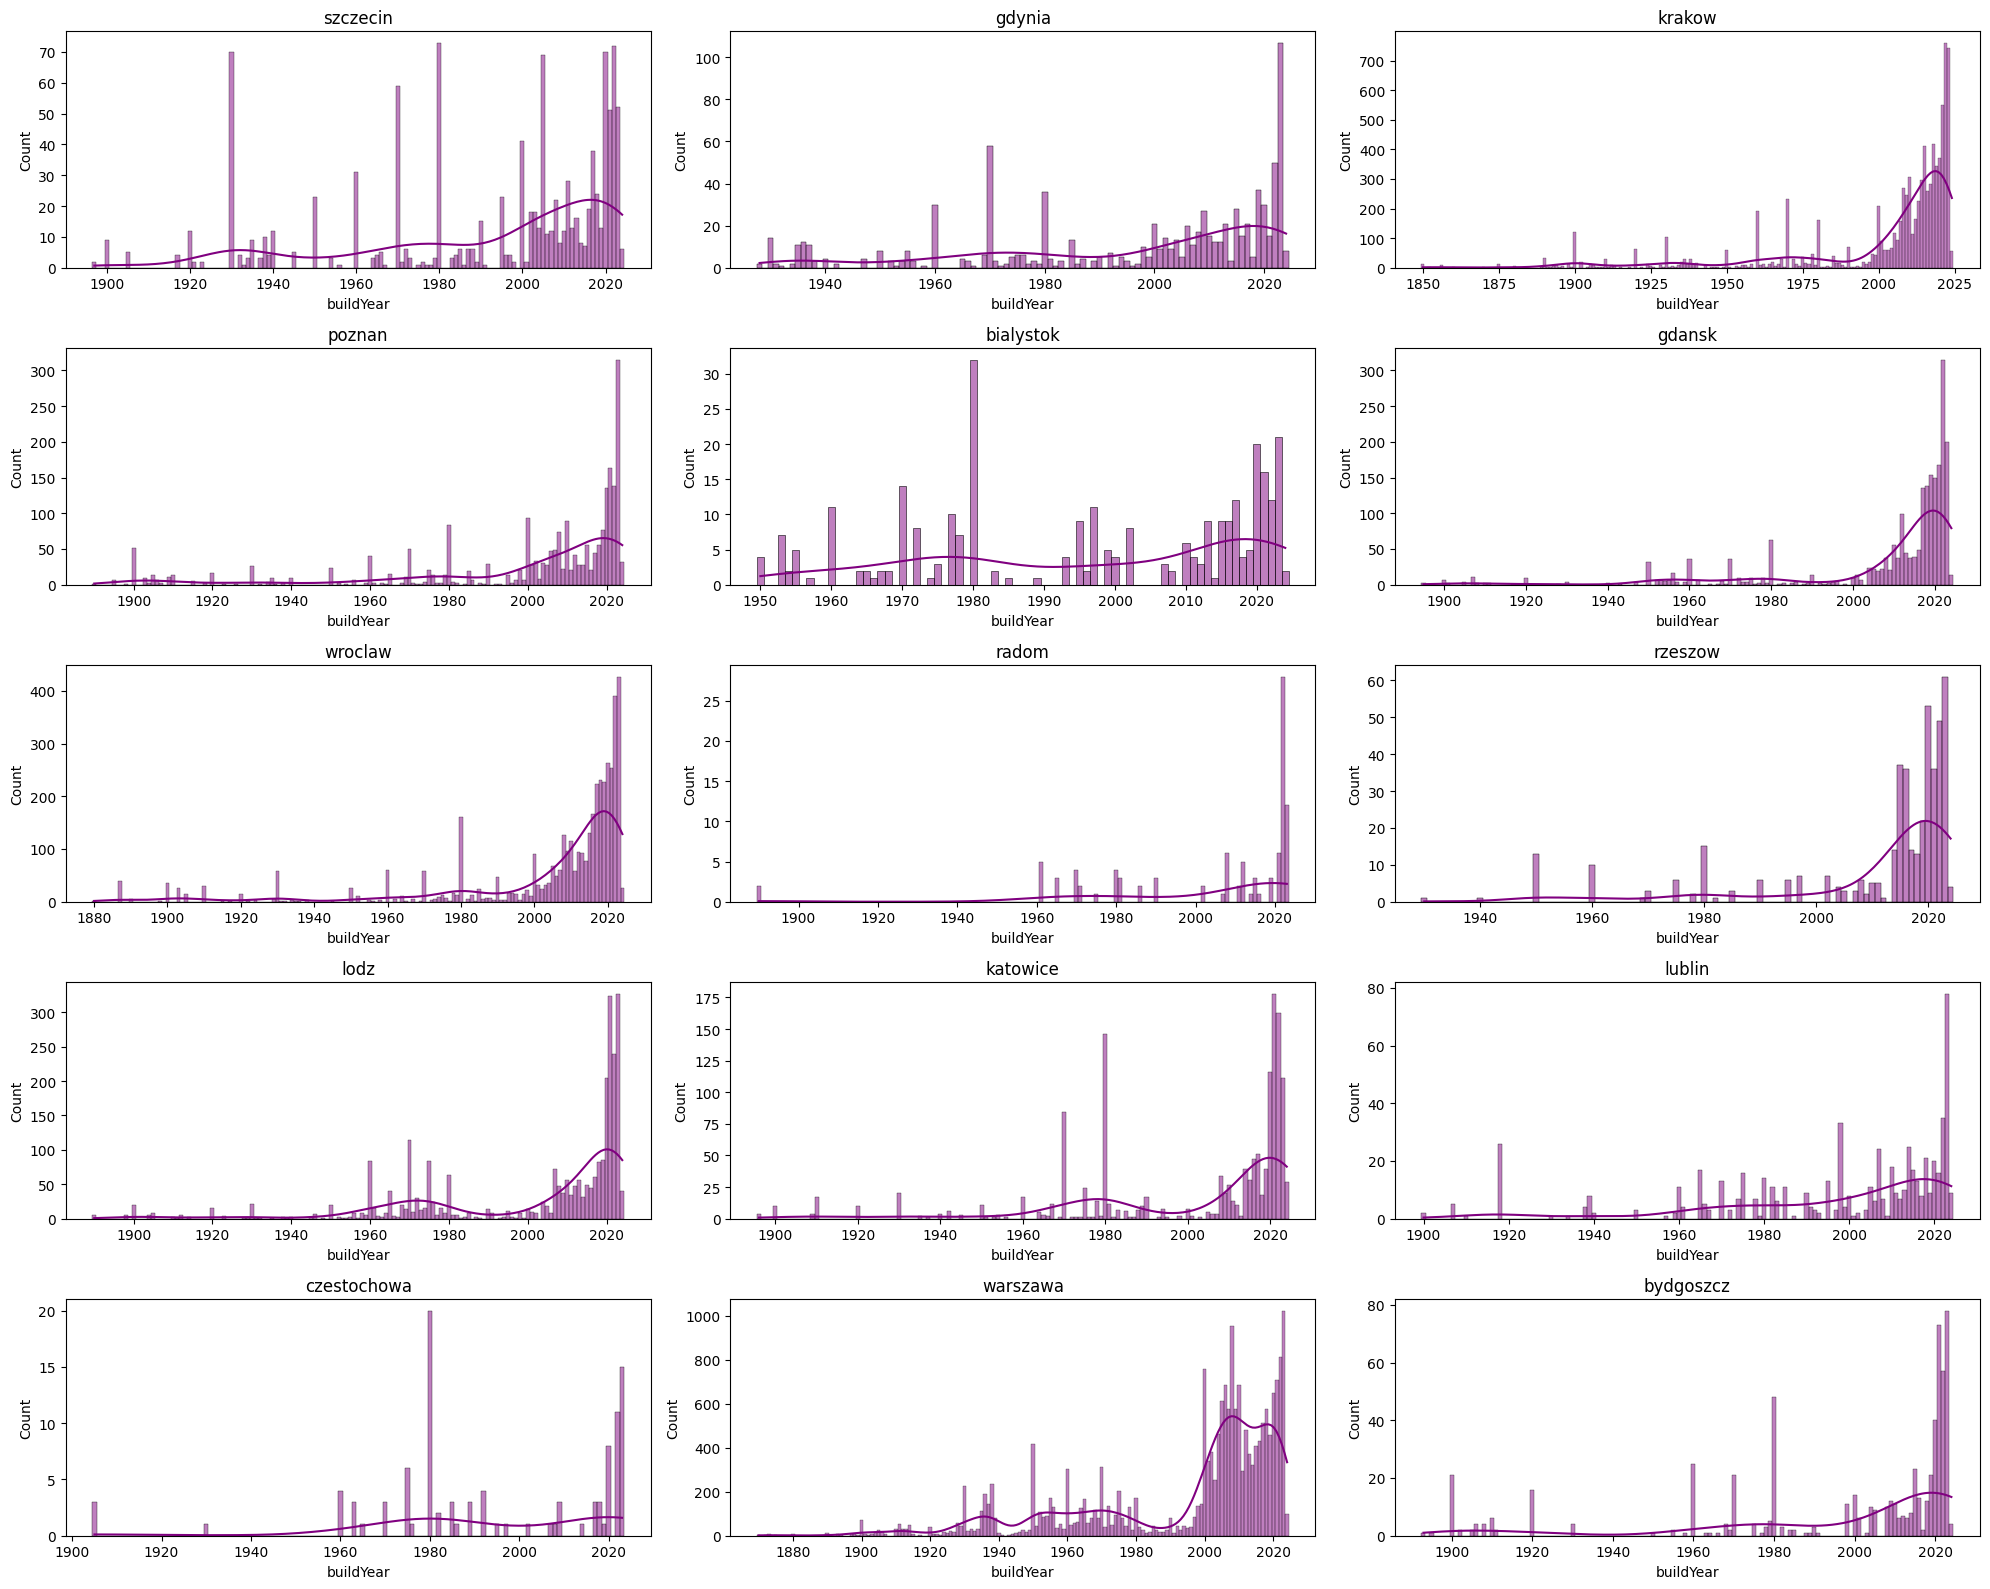

In [230]:
# Observando distribuição do buildYear para cada cidade
cidades = df["city"].unique()
fig, axes = plt.subplots(5, 3, figsize=(20, 16))
axes = axes.flatten()

for i, city in enumerate(cidades[:15]):
    sns.histplot(df[df["city"] == city]["buildYear"], bins='auto', discrete=True, kde=True, color='purple', ax=axes[i])
    axes[i].set_title(city)

plt.tight_layout()
plt.show()


In [231]:
# Randomizando preenchimento de valores nulos da coluna "buildYear"

np.random.seed(42)
anos_random = np.random.randint(1960, 2026, size=df['buildYear'].isna().sum())
df.loc[df['buildYear'].isna(), 'buildYear'] = anos_random

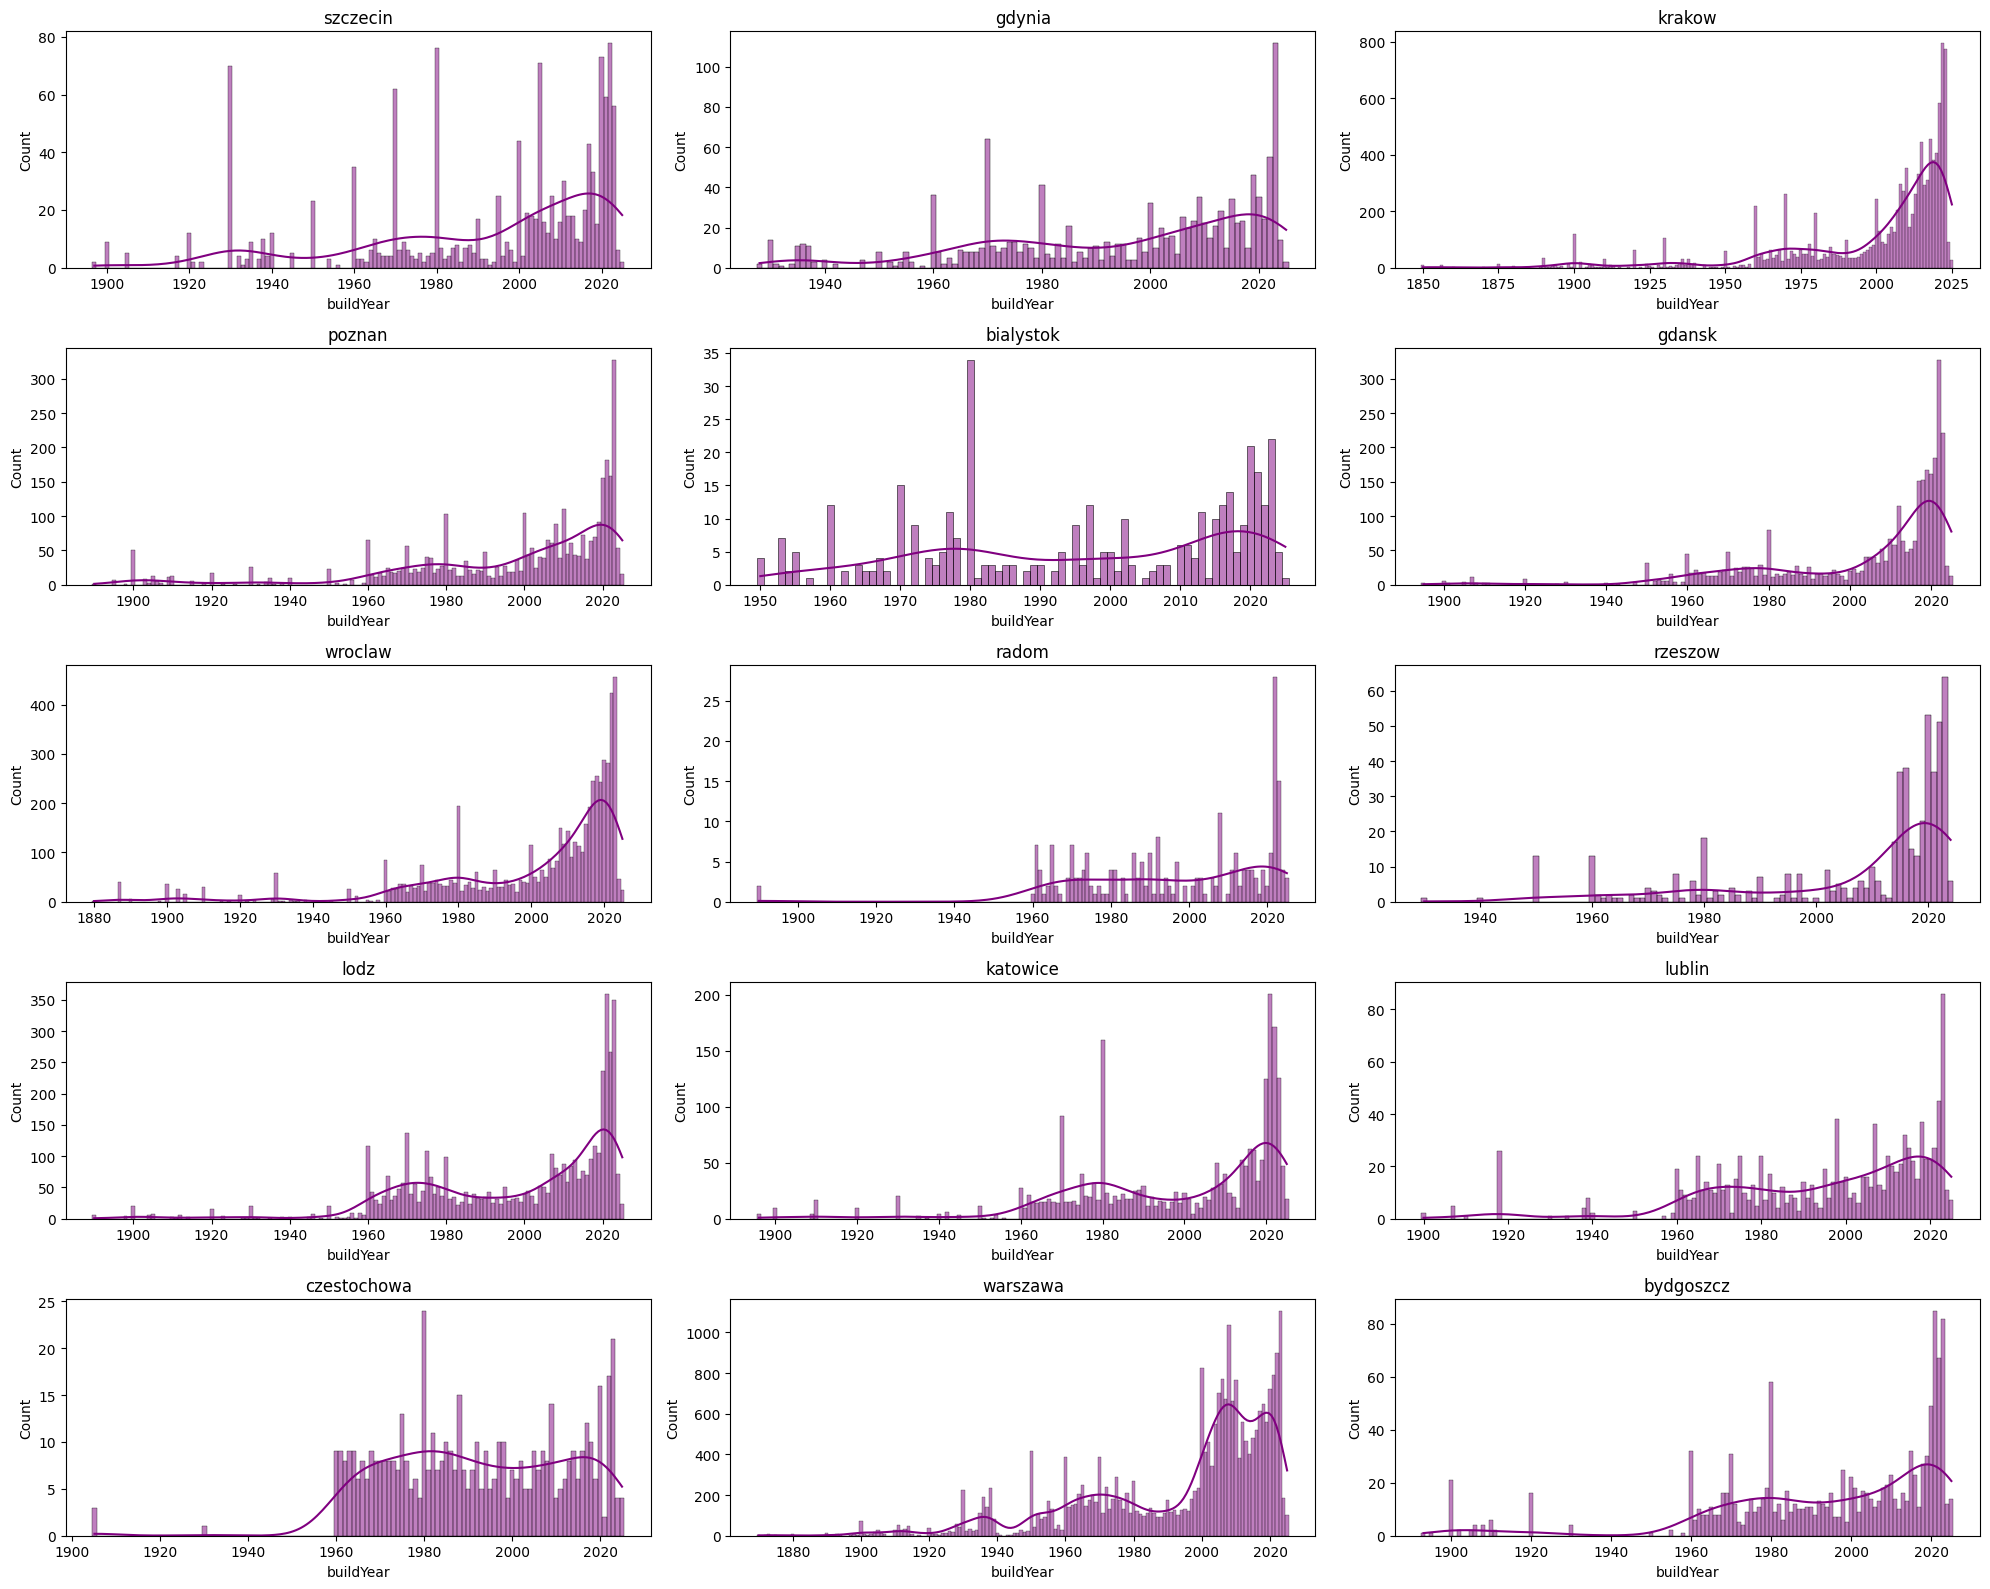

In [232]:
# Comparativo após preenchimento

cidades = df["city"].unique()
fig, axes = plt.subplots(5, 3, figsize=(20, 16))
axes = axes.flatten()

for i, city in enumerate(cidades[:15]):
    sns.histplot(df[df["city"] == city]["buildYear"], bins='auto', discrete=True, kde=True, color='purple', ax=axes[i])
    axes[i].set_title(city)

plt.tight_layout()
plt.show()

##### Tratamento Coluna schoolDistance

In [233]:
print(df["schoolDistance"].isnull().sum())

df.fillna({"schoolDistance": df["schoolDistance"].median()}, inplace=True)
print(df["schoolDistance"].isnull().sum())

10
0


##### Tratamento Coluna clinicDistance

In [234]:
print(df["clinicDistance"].isnull().sum())

df.fillna({"clinicDistance": df["clinicDistance"].median()}, inplace=True)
print(df["clinicDistance"].isnull().sum())

40
0


##### Tratamento Coluna postOfficeDistance

In [235]:
print(df["postOfficeDistance"].isnull().sum())

df.fillna({"postOfficeDistance": df["postOfficeDistance"].median()}, inplace=True)
print(df["postOfficeDistance"].isnull().sum())

19
0


##### Tratamento Coluna kindergartenDistance

In [236]:
print(df["kindergartenDistance"].isnull().sum())

df.fillna({"kindergartenDistance": df["kindergartenDistance"].median()}, inplace=True)
print(df["kindergartenDistance"].isnull().sum())

28
0


##### Tratamento Coluna restaurantDistance

In [237]:
print(df["restaurantDistance"].isnull().sum())

df.fillna({"restaurantDistance": df["restaurantDistance"].median()}, inplace=True)
print(df["restaurantDistance"].isnull().sum())

132
0


##### Tratamento Coluna collegeDistance

In [238]:
print(df["collegeDistance"].isnull().sum())

df.fillna({"collegeDistance": df["collegeDistance"].median()}, inplace=True)
print(df["collegeDistance"].isnull().sum())

662
0


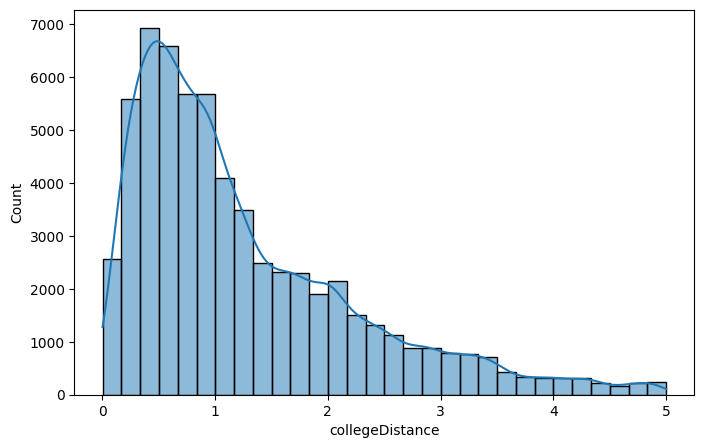

In [239]:
plt.figure(figsize=(8, 5))
sns.histplot(df["collegeDistance"], bins=30, kde=True)
plt.show()

##### Tratamento Coluna pharmacyDistance

In [240]:
print(df["pharmacyDistance"].isnull().sum())

df.fillna({"pharmacyDistance": df["pharmacyDistance"].median()}, inplace=True)
print(df["pharmacyDistance"].isnull().sum())

72
0


##### Tratamento Coluna buildingMaterial

In [241]:
print(df["buildingMaterial"].isnull().sum())

df.drop(columns=["buildingMaterial"], inplace=True)
df

25000


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,0.307,condominium,NaN,yes,yes,no,no,no,3500,11
1,996722490efcb4b34d48bb84a9a72838,szczecin,Desconecido,43.4,2.0,3.0,4.0,2011.0,53.435746,14.560764,...,0.211,condominium,NaN,no,yes,no,no,no,1900,11
2,50d75c688530b9a61ba505301e0b94a9,szczecin,apartmentBuilding,32.6,2.0,5.0,6.0,2021.0,53.421582,14.541572,...,0.192,condominium,premium,no,yes,yes,no,no,2500,11
3,9b187f4203adabf466fd08610d8f4e5e,szczecin,apartmentBuilding,72.0,3.0,6.0,6.0,2014.0,53.450010,14.547230,...,0.315,condominium,premium,no,yes,yes,no,yes,2999,11
4,ba4d70d65d1024ee13929ca82bfc92f6,szczecin,blockOfFlats,52.0,2.0,1.0,3.0,2006.0,53.427400,14.488100,...,0.458,condominium,NaN,yes,no,no,no,no,2300,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62229,4018cc5a9fd48bb2d66b84bc5e1b46ab,bydgoszcz,tenement,55.0,3.0,2.0,2.0,2017.0,53.129551,18.029431,...,0.024,condominium,NaN,no,no,no,no,no,3200,6
62230,89fdf9ecda6fe6aa95e34528fa82f55f,bydgoszcz,blockOfFlats,48.0,2.0,3.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,NaN,no,no,no,no,no,2700,6
62231,095b187d0bbce092d4b03164e89710c5,bydgoszcz,blockOfFlats,50.0,2.0,1.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,NaN,no,yes,no,no,no,2800,6
62232,eee39c309b4f55e057485d848bb2772b,bydgoszcz,Desconecido,40.0,2.0,1.0,1.0,2002.0,53.126000,18.007900,...,0.205,condominium,NaN,no,no,NaN,no,no,1500,6


##### Tratamento Coluna condition

In [242]:
print(df["condition"].isnull().sum())

df.drop(columns=["condition"], inplace=True)
df

45193


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,collegeDistance,pharmacyDistance,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,mes
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,2.200,0.307,condominium,yes,yes,no,no,no,3500,11
1,996722490efcb4b34d48bb84a9a72838,szczecin,Desconecido,43.4,2.0,3.0,4.0,2011.0,53.435746,14.560764,...,0.714,0.211,condominium,no,yes,no,no,no,1900,11
2,50d75c688530b9a61ba505301e0b94a9,szczecin,apartmentBuilding,32.6,2.0,5.0,6.0,2021.0,53.421582,14.541572,...,0.689,0.192,condominium,no,yes,yes,no,no,2500,11
3,9b187f4203adabf466fd08610d8f4e5e,szczecin,apartmentBuilding,72.0,3.0,6.0,6.0,2014.0,53.450010,14.547230,...,1.387,0.315,condominium,no,yes,yes,no,yes,2999,11
4,ba4d70d65d1024ee13929ca82bfc92f6,szczecin,blockOfFlats,52.0,2.0,1.0,3.0,2006.0,53.427400,14.488100,...,3.003,0.458,condominium,yes,no,no,no,no,2300,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62229,4018cc5a9fd48bb2d66b84bc5e1b46ab,bydgoszcz,tenement,55.0,3.0,2.0,2.0,2017.0,53.129551,18.029431,...,1.033,0.024,condominium,no,no,no,no,no,3200,6
62230,89fdf9ecda6fe6aa95e34528fa82f55f,bydgoszcz,blockOfFlats,48.0,2.0,3.0,3.0,2019.0,53.121200,17.992500,...,0.268,0.300,condominium,no,no,no,no,no,2700,6
62231,095b187d0bbce092d4b03164e89710c5,bydgoszcz,blockOfFlats,50.0,2.0,1.0,3.0,2019.0,53.121200,17.992500,...,0.268,0.300,condominium,no,yes,no,no,no,2800,6
62232,eee39c309b4f55e057485d848bb2772b,bydgoszcz,Desconecido,40.0,2.0,1.0,1.0,2002.0,53.126000,18.007900,...,0.622,0.205,condominium,no,no,NaN,no,no,1500,6


##### Tratamento Coluna hasElevator

In [243]:
print(df["hasElevator"].isnull().sum())

print(df["hasElevator"].value_counts(dropna=False))

2909
hasElevator
yes    40383
no     18942
NaN     2909
Name: count, dtype: int64


In [244]:
df.loc[df['hasElevator'].isna(), 'hasElevator'] = np.random.choice(['yes','no'], df['hasElevator'].isna().sum(), p=[0.7,0.3])

print(df["hasElevator"].isnull().sum())

print(df["hasElevator"].value_counts(dropna=False))

0
hasElevator
yes    42440
no     19794
Name: count, dtype: int64


### ===================================================================================

In [245]:
df.to_csv("../dados/processado/apartments_rent_processed.csv", index=False)

### ===================================================================================